# Analysis -- polblogs (complex network)

Reads `results_dp_sbm_polblogs.csv` from `script_polblogs.py`.

polblogs is ONE fixed real graph, so unlike the synthetic notebook there is
no N axis: every figure is a single panel over epsilon. Two consequences
worth keeping in mind while reading:

* **Rep variance is mechanism variance only.** All reps run on the same
  adjacency, so the error bars here do NOT include graph randomness and are
  not comparable to the synthetic notebook's.
* **`beta_true_*` are empirical, not planted.** polblogs has no generating
  parameters; the reference is the block-pair density under the ground-truth
  labels, so the dashed line is an estimate too.


In [1]:
# -- load results (handles both single-file and sharded output) --------------
import glob
import numpy as np
import pandas as pd

OUTPUT_CSV = "./results/results_dp_sbm_polblogs.csv"   # match OUTPUT_CSV in the driver

shard_files = sorted(glob.glob(f"{OUTPUT_CSV}.shard*"))
if shard_files:
    df = pd.concat([pd.read_csv(f) for f in shard_files], ignore_index=True)
    print(f"Loaded {len(shard_files)} shard files, {len(df)} rows total.")
else:
    df = pd.read_csv(OUTPUT_CSV)
    print(f"Loaded {OUTPUT_CSV}, {len(df)} rows.")

_bad = df.loc[df["epsilon"] > 700, "sigma"].unique()
assert len(_bad) == 0, f"epsilon > 700 at sigma={_bad}: exp() overflowed in edge_flip"

assert df["N"].nunique() == 1, f"expected one fixed N, got {sorted(df.N.unique())}"
N_FIXED = int(df["N"].iloc[0])

print()
print(f"  N      : {N_FIXED} (fixed -- polblogs LCC)")
print("  sigma  :", sorted(df["sigma"].unique()))
print("  method :", sorted(df["method"].unique()))
print("  reps   :", sorted(df.groupby(["sigma", "method"]).size().unique()), "rows per cell")
df.head()

Loaded ./results/results_dp_sbm_polblogs.csv, 300 rows.

  N      : 1222 (fixed -- polblogs LCC)
  sigma  : [1.0, 2.0, 5.0, 10.0, 20.0]
  method : ['edge_flip_spectral', 'edge_flip_vem', 'sbm_dpsgd_all_noised']
  reps   : [20] rows per cell


,N,sigma,epsilon,rep,method,epsilon_gamma,epsilon_beta,epochs,epochs_gamma,epochs_beta,delta,beta_true_00,beta_true_01,beta_true_11,beta_est_00,beta_est_01,beta_est_11,nmi
0,1222,1.0,27.438806,0,edge_flip_vem,NaN,NaN,292.000000,NaN,NaN,0.00001,0.042592,0.004226,0.038825,0.159289,0.022182,0.002109,0.000435
1,1222,1.0,27.438806,0,edge_flip_spectral,NaN,NaN,NaN,NaN,NaN,0.00001,0.042592,0.004226,0.038825,0.022547,0.000205,0.666667,0.005999
2,1222,1.0,27.438806,0,sbm_dpsgd_all_noised,26.327698,5.635909,10.999985,5.999992,4.999993,0.00001,0.042592,0.004226,0.038825,0.121153,0.012693,0.124133,0.121332
3,1222,1.0,27.438806,1,edge_flip_vem,NaN,NaN,277.000000,NaN,NaN,0.00001,0.042592,0.004226,0.038825,0.159289,0.022182,0.002109,0.000435
4,1222,1.0,27.438806,1,edge_flip_spectral,NaN,NaN,NaN,NaN,NaN,0.00001,0.042592,0.004226,0.038825,0.022547,0.000205,0.666667,0.005999


## Coverage


In [2]:
# -- which (sigma, method) cells are complete? -------------------------------
counts = (df.groupby(["sigma", "method"]).size()
            .unstack("method").fillna(0).astype(int))
expected = int(counts.values.max()) if counts.size else 0
print(f"expected reps per cell (max seen): {expected}\n")
print(counts.to_string())

missing = counts[(counts < expected).any(axis=1)]
print("\nINCOMPLETE cells:\n" + missing.to_string() if len(missing) else "\nAll cells complete.")

# epochs is written for edge_flip_vem and sbm_dpsgd only -- spectral has no
# iterative epoch to count, so its blank column is expected, not a gap.
print("\nnon-null `epochs` by method:")
print(df.groupby("method")["epochs"].apply(lambda s: f"{s.notna().sum()}/{len(s)}").to_string())

# one shared epsilon per sigma is the whole point of the matched design
print("\ndistinct epsilon per sigma (must all be 1):")
print(df.groupby("sigma")["epsilon"].nunique().to_string())

expected reps per cell (max seen): 20

method  edge_flip_spectral  edge_flip_vem  sbm_dpsgd_all_noised
sigma                                                          
1.0                     20             20                    20
2.0                     20             20                    20
5.0                     20             20                    20
10.0                    20             20                    20
20.0                    20             20                    20

All cells complete.

non-null `epochs` by method:
method
edge_flip_spectral        0/100
edge_flip_vem           100/100
sbm_dpsgd_all_noised    100/100

distinct epsilon per sigma (must all be 1):
sigma
1.0     1
2.0     1
5.0     1
10.0    1
20.0    1


## Why edge-flip struggles here

polblogs is **sparse** -- density ~0.022 -- while edge-flip adds noise at
rate `p_flip` across ALL pairs. When `p_flip` approaches the graph's own
density, the release contains more spurious edges than real ones and the
block signal is buried. This cell quantifies that per epsilon; it is the
single most useful thing to read before interpreting the NMI figure.


In [3]:
# -- noise vs signal, per epsilon --------------------------------------------
M_pairs = N_FIXED * (N_FIXED - 1) / 2
n_edges = df["beta_true_00"].iloc[0]  # placeholder, recomputed properly below

b00 = df["beta_true_00"].iloc[0]
b01 = df["beta_true_01"].iloc[0]
b11 = df["beta_true_11"].iloc[0]
beta_intra = (b00 + b11) / 2

# real edge count implied by the empirical block densities
real_edges = None
try:
    import sys; sys.path.insert(0, ".")
    import script_polblogs as SP
    A_np, labels = SP.load_polblogs(SP.resolve_data_path())
    real_edges = int(A_np.sum() / 2)
    density = real_edges / M_pairs
except Exception as exc:                      # analysis must work without the gml
    print(f"(could not load the graph: {exc}; using block densities instead)")
    density = beta_intra * 0.5 + b01 * 0.5
    real_edges = int(density * M_pairs)

print(f"N = {N_FIXED}   pairs = {int(M_pairs):,}   edges = {real_edges:,}   "
      f"density = {density:.5f}")
print(f"empirical beta: intra = {beta_intra:.4f}   inter = {b01:.4f}   "
      f"contrast = {beta_intra / b01:.1f}x\n")

rows = []
for eps in sorted(df["epsilon"].unique()):
    p = 1.0 / (1.0 + np.exp(eps))
    added = p * M_pairs
    # post-flip observed densities: obs = (1 - 2p) * beta + p
    oi = (1 - 2 * p) * beta_intra + p
    oo = (1 - 2 * p) * b01 + p
    rows.append(dict(epsilon=round(eps, 3), p_flip=p,
                     spurious_edges=int(added),
                     ratio_to_real=added / max(real_edges, 1),
                     obs_intra=oi, obs_inter=oo,
                     obs_contrast=oi / oo if oo > 0 else np.inf))
noise = pd.DataFrame(rows).set_index("epsilon")
print(noise.round(4).to_string())
print("\n`ratio_to_real` > 1 means the release has more spurious edges than real ones.")
print("`obs_contrast` -> 1 means the two blocks look identical after flipping.")

N = 1222   pairs = 746,031   edges = 16,715   density = 0.02241
empirical beta: intra = 0.0407   inter = 0.0042   contrast = 9.6x

         p_flip  spurious_edges  ratio_to_real  obs_intra  obs_inter  obs_contrast
epsilon                                                                           
0.977    0.2734          203972        12.2030     0.2919     0.2753        1.0600
1.995    0.1198           89353         5.3457     0.1507     0.1230        1.2256
4.148    0.0155           11595         0.6937     0.0550     0.0196        2.8000
11.729   0.0000               6         0.0004     0.0407     0.0042        9.6166
27.439   0.0000               0         0.0000     0.0407     0.0042        9.6330

`ratio_to_real` > 1 means the release has more spurious edges than real ones.
`obs_contrast` -> 1 means the two blocks look identical after flipping.


## NMI


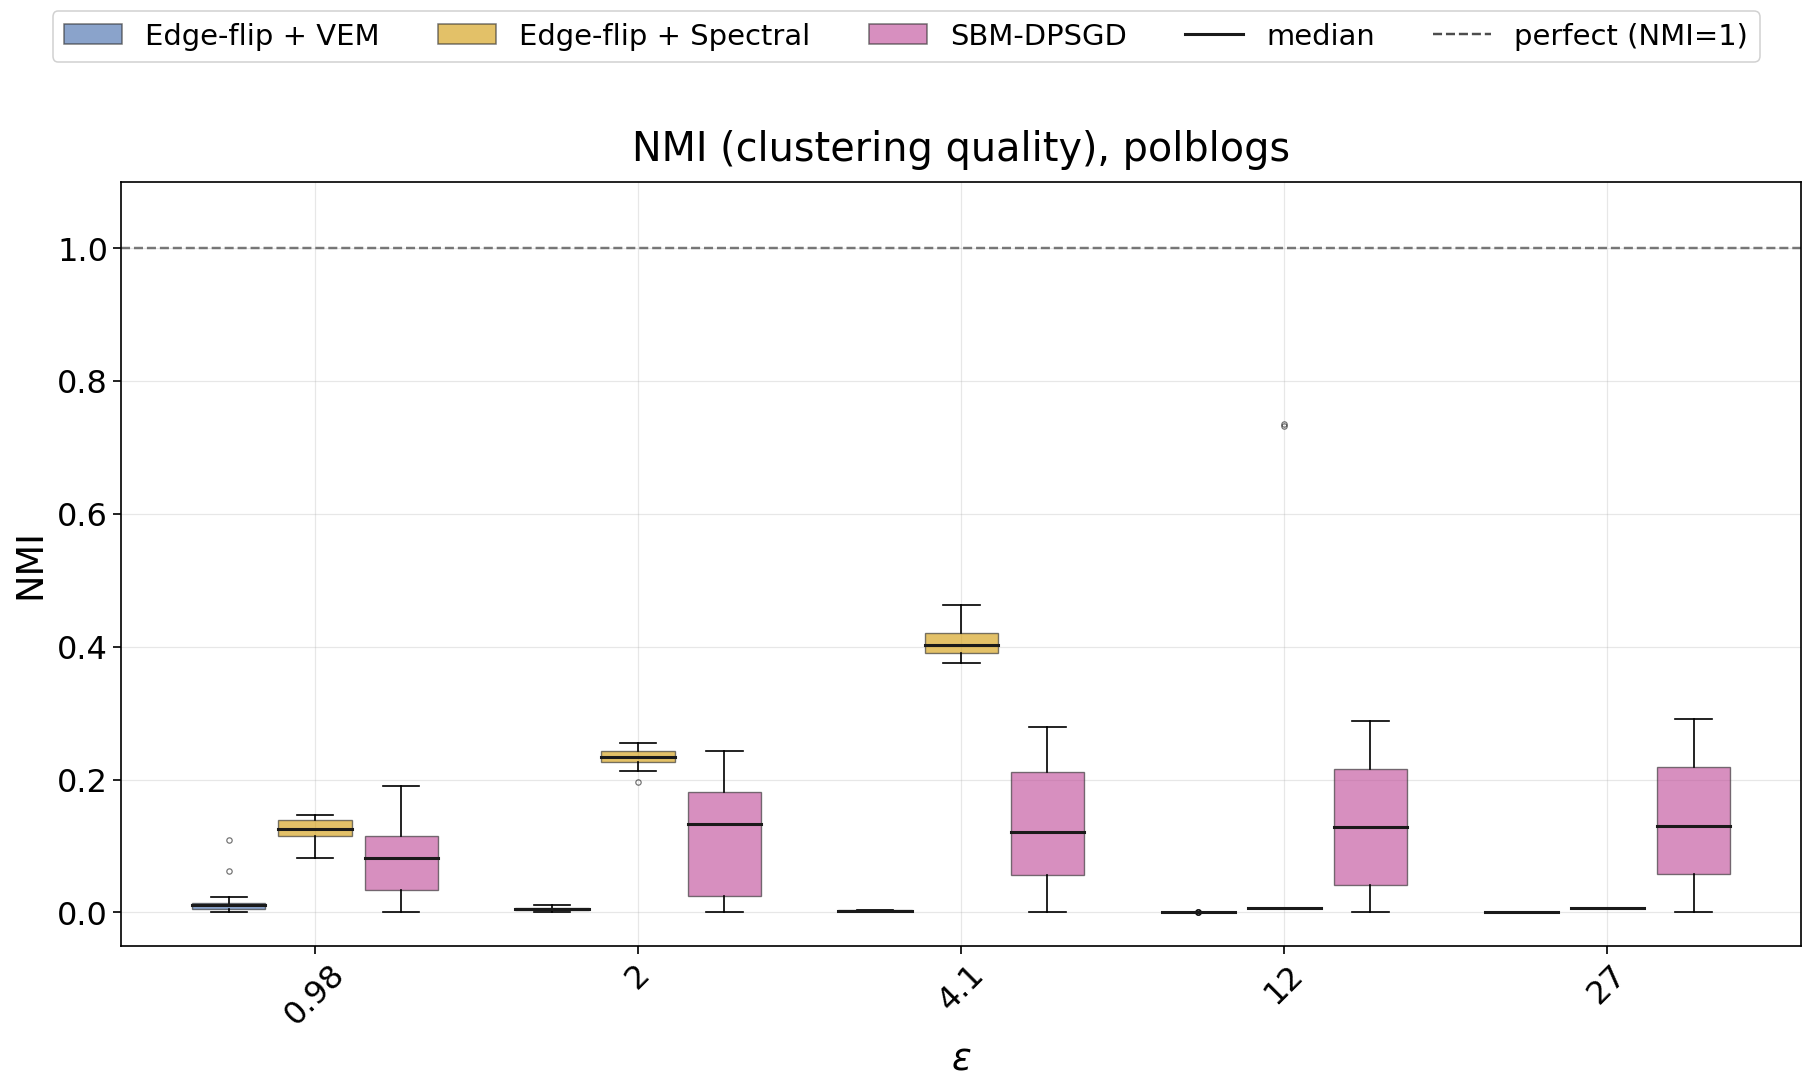

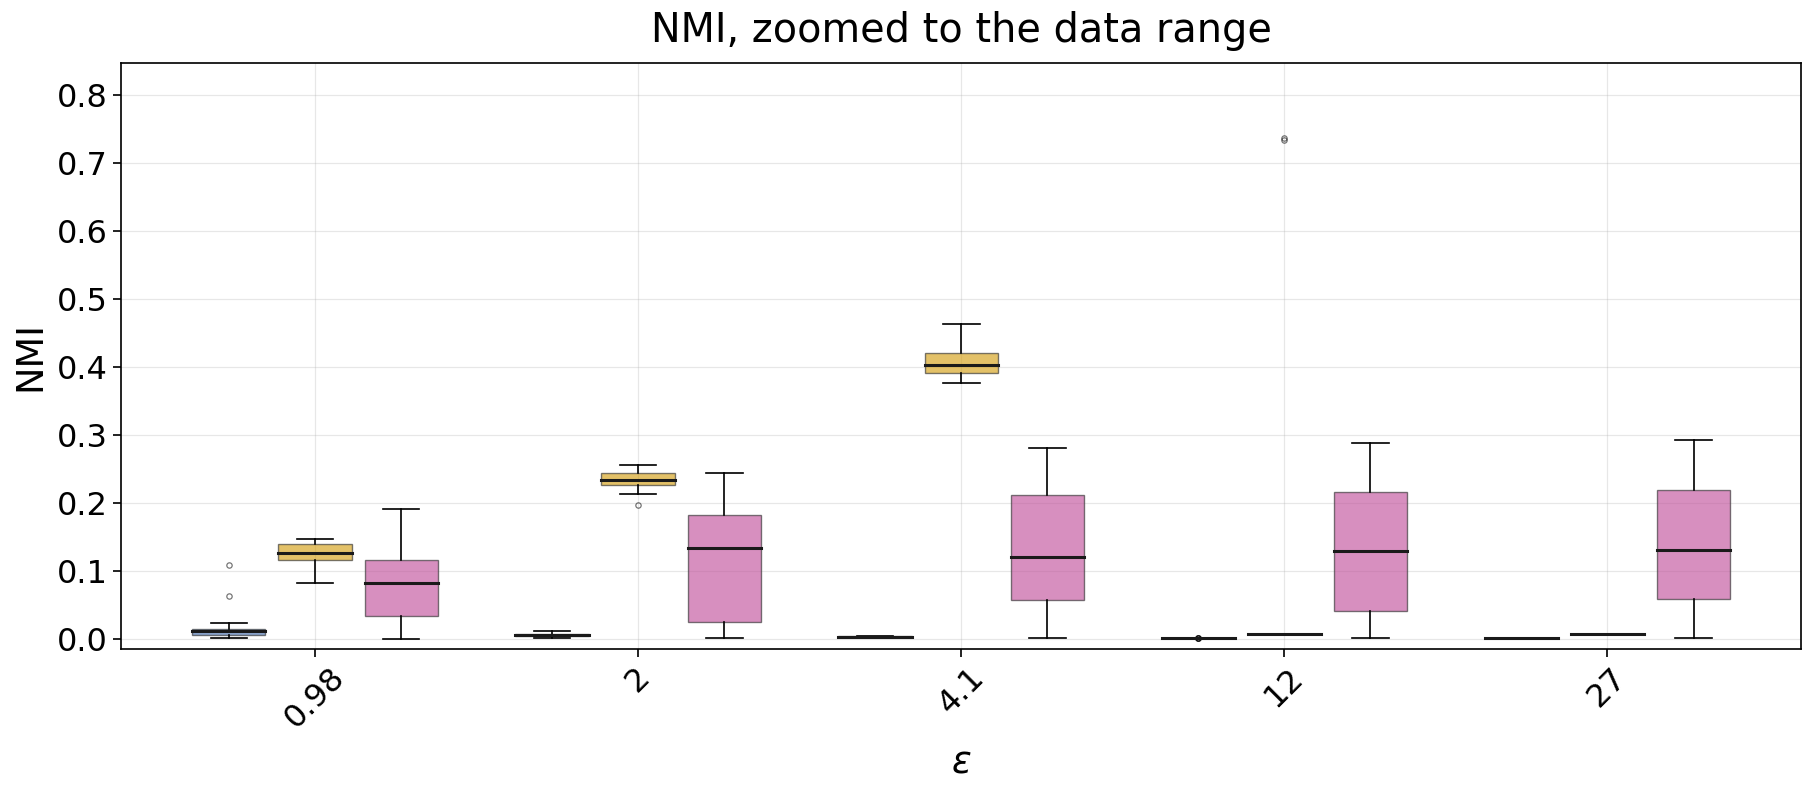

In [4]:
# -- Boxplot of NMI vs epsilon -----------------------------------------------
# Single fixed graph, so a single large panel.  Enlarged on both axes of
# "bigger": a wider canvas AND larger type, since point sizes are absolute and
# growing the canvas alone would leave the text looking smaller on it.  Tick
# labels resize only through rcParams, so the type bump goes through a scoped
# rc_context.
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from plot_style import (apply_style, figsize, grouped_boxplot, method_color,
                        method_label, order_methods, reference_line,
                        BOX_ALPHA, MEDIAN_COLOR, REFERENCE_COLOR)

apply_style()

methods = order_methods(df["method"].unique())
sub = df.dropna(subset=["nmi"])

PANEL_W, PANEL_H = 12.5, 7.5
NMI_RC = {"font.size": 20, "axes.labelsize": 24, "xtick.labelsize": 21,
          "ytick.labelsize": 21, "legend.fontsize": 20}

with plt.rc_context(NMI_RC):
    fig, ax = plt.subplots(figsize=figsize(PANEL_W, PANEL_H))
    grouped_boxplot(ax, sub, "nmi", methods=methods)
    reference_line(ax, 1.0)
    ax.set_ylim(-0.05, 1.1)
    ax.set_title("NMI (clustering quality), polblogs", fontsize=26, pad=14)
    ax.set_xlabel(r"$\epsilon$")
    ax.set_ylabel("NMI", fontsize=24)

    handles = [Patch(facecolor=method_color(m), alpha=BOX_ALPHA,
                     edgecolor="#333333", label=method_label(m)) for m in methods]
    handles += [
        Line2D([0], [0], color=MEDIAN_COLOR, linewidth=2.0, label="median"),
        Line2D([0], [0], color=REFERENCE_COLOR, linestyle="--", linewidth=1.6,
               label="perfect (NMI=1)"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=len(handles),
               fontsize=19, frameon=True, bbox_to_anchor=(0.5, 1.0))
    fig.tight_layout(rect=[0, 0, 1, 0.91])
    fig.savefig("figures/nmi_polblogs.png", dpi=200)
    plt.show()

# NMI here is LOW for every method by synthetic-benchmark standards -- do not
# read the y-axis as if 1.0 were in reach.  Zoom to the data as well.
with plt.rc_context(NMI_RC):
    fig, ax = plt.subplots(figsize=figsize(PANEL_W, PANEL_H * 0.75))
    grouped_boxplot(ax, sub, "nmi", methods=methods)
    top = sub["nmi"].max()
    ax.set_ylim(-0.02 * max(top, 0.05), max(top, 0.05) * 1.15)
    ax.set_title("NMI, zoomed to the data range", fontsize=26, pad=14)
    ax.set_xlabel(r"$\epsilon$")
    ax.set_ylabel("NMI", fontsize=24)
    fig.tight_layout()
    plt.show()

### Per-rep spread

All reps share one graph, so any spread here is DP-mechanism randomness (and
optimizer randomness) alone. A cell whose points split between two extremes
is bimodal, and its mean describes no run that actually happened.


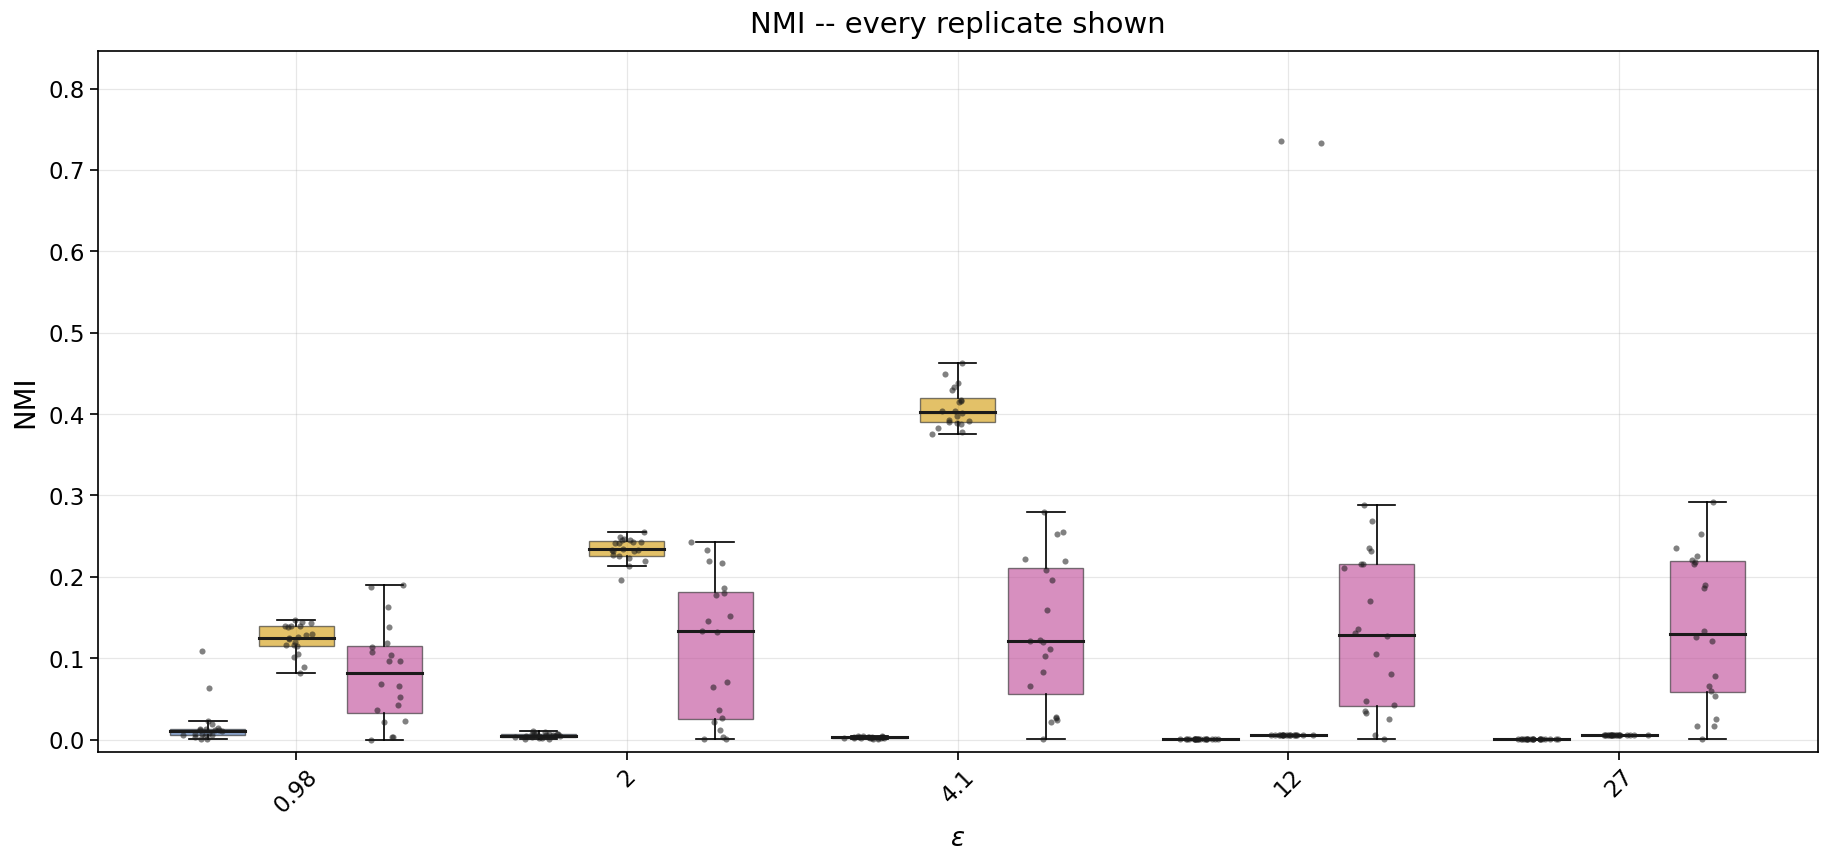

                              mean     std     min     max
sigma method                                              
1.0   edge_flip_spectral    0.0060  0.0000  0.0060  0.0060
      edge_flip_vem         0.0004  0.0000  0.0004  0.0004
      sbm_dpsgd_all_noised  0.1368  0.0922  0.0002  0.2919
2.0   edge_flip_spectral    0.0788  0.2242  0.0060  0.7360
      edge_flip_vem         0.0004  0.0001  0.0002  0.0006
      sbm_dpsgd_all_noised  0.1302  0.0938  0.0009  0.2881
5.0   edge_flip_spectral    0.4076  0.0242  0.3760  0.4622
      edge_flip_vem         0.0027  0.0009  0.0005  0.0041
      sbm_dpsgd_all_noised  0.1309  0.0887  0.0001  0.2797
10.0  edge_flip_spectral    0.2338  0.0139  0.1960  0.2547
      edge_flip_vem         0.0051  0.0027  0.0011  0.0111
      sbm_dpsgd_all_noised  0.1127  0.0871  0.0011  0.2430
20.0  edge_flip_spectral    0.1234  0.0183  0.0817  0.1470
      edge_flip_vem         0.0171  0.0252  0.0007  0.1084
      sbm_dpsgd_all_noised  0.0816  0.0596  0.0000  0.19

In [5]:
# -- every rep, jittered over the box ----------------------------------------
from plot_style import box_positions

apply_style()
rng = np.random.default_rng(0)
eps_vals = sorted(df["epsilon"].unique())

fig, ax = plt.subplots(figsize=figsize(12.5, 6.0))
grouped_boxplot(ax, sub, "nmi", methods=methods, showfliers=False)
pos_map, width = box_positions(methods, eps_vals)
for ev in eps_vals:
    for m in methods:
        v = sub.loc[(sub["epsilon"] == ev) & (sub["method"] == m), "nmi"].values
        if len(v) == 0:
            continue
        ax.scatter(pos_map[(ev, m)] + rng.normal(0, width * 0.12, len(v)), v,
                   s=16, color="#1A1A1A", alpha=0.55, zorder=4, linewidths=0)
top = sub["nmi"].max()
ax.set_ylim(-0.02 * max(top, 0.05), max(top, 0.05) * 1.15)
ax.set_xlabel(r"$\epsilon$")
ax.set_ylabel("NMI", fontsize=18)
ax.set_title("NMI -- every replicate shown", fontsize=19, pad=12)
plt.tight_layout()
plt.show()

# Collapse rate: how often a method failed OUTRIGHT, read next to the mean.
# The absolute threshold used in the synthetic notebook (0.15) is far too high
# for polblogs, where good runs sit around 0.2-0.3 -- so it is set RELATIVE to
# the best cell seen for that method.
def summarize(g):
    v = g["nmi"].dropna()
    return pd.Series({"mean": v.mean(), "std": v.std(), "min": v.min(), "max": v.max()})

tbl = df.groupby(["sigma", "method"]).apply(summarize).round(4)
print(tbl.to_string())

print("\ncollapse rate (fraction of reps below 20% of that method's best cell mean):")
best = df.groupby("method")["nmi"].mean().groupby(level=0).max()
means = df.groupby(["sigma", "method"])["nmi"].mean()
thresh = {m: 0.2 * df[df["method"] == m].groupby("sigma")["nmi"].mean().max()
          for m in df["method"].unique()}
coll = (df.assign(fail=df.apply(lambda r: r["nmi"] < thresh[r["method"]], axis=1))
          .groupby(["sigma", "method"])["fail"].mean().unstack("method").round(2))
print(coll.to_string())
print("\nthresholds used:", {k: round(v, 4) for k, v in thresh.items()})

## Estimated beta

The dashed reference is the **empirical** block density under ground-truth
labels, not a planted parameter. Intra and inter are on separate scales --
they differ by ~10x and a shared axis would flatten the inter panel.


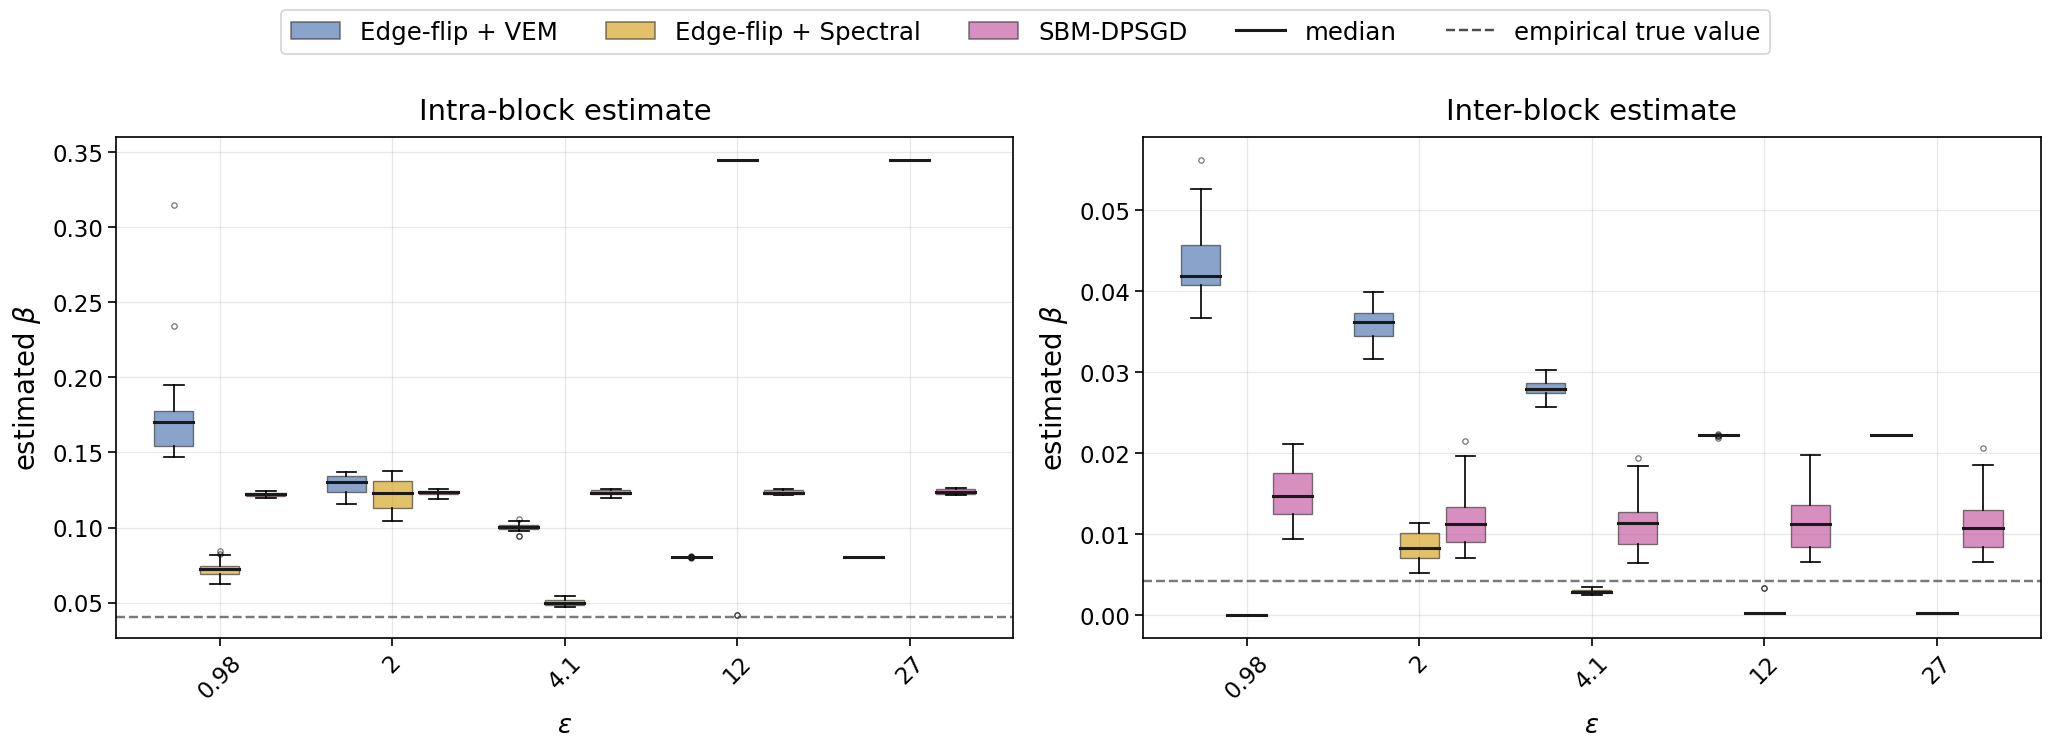

empirical reference: intra = 0.0407   inter = 0.0042

CAVEAT: a beta estimate is only meaningful if the LABELS are right.
Where NMI ~ 0 the blocks are essentially arbitrary, so beta_est there
describes a random 2-partition of the graph, not the real communities.


In [6]:
# -- Boxplots of estimated beta vs epsilon -----------------------------------
apply_style()

PANEL_W_B, PANEL_H_B = 7.0, 5.0
true_00 = df["beta_true_00"].iloc[0]
true_01 = df["beta_true_01"].iloc[0]
true_11 = df["beta_true_11"].iloc[0]
df["intra_est"] = df[["beta_est_00", "beta_est_11"]].mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=figsize(PANEL_W_B * 2, PANEL_H_B))

for ax, (est_col, true_val, title) in zip(axes, [
    ("intra_est", (true_00 + true_11) / 2, "Intra-block estimate"),
    ("beta_est_01", true_01, "Inter-block estimate"),
]):
    grouped_boxplot(ax, df, est_col, methods=methods)
    reference_line(ax, true_val)
    ax.set_title(title, fontsize=19, pad=12)
    ax.set_xlabel(r"$\epsilon$")
    ax.set_ylabel(r"estimated $\beta$", fontsize=18)

handles = [Patch(facecolor=method_color(m), alpha=BOX_ALPHA, edgecolor="#333333",
                 label=method_label(m)) for m in methods]
handles += [
    Line2D([0], [0], color=MEDIAN_COLOR, linewidth=2.0, label="median"),
    Line2D([0], [0], color=REFERENCE_COLOR, linestyle="--", linewidth=1.6,
           label="empirical true value"),
]
fig.legend(handles=handles, loc="upper center", ncol=len(handles),
           fontsize=16, frameon=True, bbox_to_anchor=(0.5, 1.03))

plt.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig("figures/beta_polblogs.png", dpi=200, bbox_inches="tight")
plt.show()

print("empirical reference: intra = %.4f   inter = %.4f" %
      ((true_00 + true_11) / 2, true_01))
print("\nCAVEAT: a beta estimate is only meaningful if the LABELS are right.")
print("Where NMI ~ 0 the blocks are essentially arbitrary, so beta_est there")
print("describes a random 2-partition of the graph, not the real communities.")

## Compute cost (epochs)

**Not wall-clock comparable across methods.** A VEM epoch is a dense O(N^2)
matmul pass; an SBM-DPSGD epoch is a sampled per-example autodiff pass.
`edge_flip_spectral` is absent by construction -- spectral clustering has no
iterative epoch to count.


In [ ]:
# -- Boxplots of # epochs vs epsilon -----------------------------------------
apply_style()

df_ep = df.dropna(subset=["epochs"])
methods_ep = order_methods(df_ep["method"].unique())
print("methods with an epoch count:", methods_ep)

fig, ax = plt.subplots(figsize=figsize(11.0, 5.5))
grouped_boxplot(ax, df_ep, "epochs", methods=methods_ep)
ax.set_yscale("log")
ax.set_xlabel(r"$\epsilon$")
ax.set_ylabel("epochs", fontsize=18)
ax.set_title("Compute cost (epochs, log scale), polblogs", fontsize=19, pad=12)

handles = [Patch(facecolor=method_color(m), alpha=BOX_ALPHA, edgecolor="#333333",
                 label=method_label(m)) for m in methods_ep]
handles += [Line2D([0], [0], color=MEDIAN_COLOR, linewidth=2.0, label="median")]
fig.legend(handles=handles, loc="upper center", ncol=len(handles),
           fontsize=16, frameon=True, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig("figures/epochs_polblogs.png", dpi=200, bbox_inches="tight")
plt.show()

## Dataset description

Numbers for the methods section. This **imports** `script_polblogs` rather
than reproducing its loading logic, so the description cannot drift from what
the experiment actually ran on.


In [ ]:
# -- dataset numbers, straight from the driver's own loader ------------------
import sys
sys.path.insert(0, ".")
import networkx as nx
import script_polblogs as SP

path = SP.resolve_data_path()
G_raw = nx.read_gml(path)
G = nx.Graph(G_raw).to_undirected()
A_np, labels = SP.load_polblogs(path)            # same call the driver makes
n_nodes = A_np.shape[0]
n_edges = int(A_np.sum() / 2)
b00, b01, b11 = SP.empirical_betas(A_np, labels)
deg = A_np.sum(axis=1)
counts = np.bincount(labels)

print("-- preprocessing trail --------------------------------------------")
print(f"raw GML                     : {G_raw.number_of_nodes()} nodes, "
      f"{G_raw.number_of_edges()} directed edges ({type(G_raw).__name__})")
print(f"simple + undirected         : {G.number_of_nodes()} nodes, "
      f"{G.number_of_edges()} edges, {nx.number_connected_components(G)} components")
print(f"largest connected component : {n_nodes} nodes, {n_edges} edges")
print()
print("-- numbers for the sentence ---------------------------------------")
print(f"N                = {n_nodes}")
print(f"|E|              = {n_edges}")
print(f"density          = {n_edges / (n_nodes * (n_nodes - 1) / 2):.5f}")
print(f"block sizes      = liberal {counts[0]}, conservative {counts[1]}")
print(f"mean degree      = {deg.mean():.2f}   median {np.median(deg):.0f}   max {int(deg.max())}")
print(f"degree skew      = top-1% of nodes hold "
      f"{deg[deg >= np.quantile(deg, 0.99)].sum() / deg.sum():.1%} of edge endpoints")
print(f"empirical beta   = intra {(b00 + b11) / 2:.4f} (lib {b00:.4f}, con {b11:.4f}), "
      f"inter {b01:.4f}")
print(f"assortativity    = intra/inter contrast {((b00 + b11) / 2) / b01:.1f}x")
print()
print("The heavy degree tail matters: the SBM assumes within-block degree")
print("homogeneity, so a graph this skewed is only approximately 2-block --")
print("part of the NMI ceiling here is model mis-specification, not privacy.")

## Summary table


In [ ]:
# -- numbers behind the figures ----------------------------------------------
summary = (df.groupby(["sigma", "epsilon", "method"])
             .agg(nmi_mean=("nmi", "mean"), nmi_std=("nmi", "std"),
                  nmi_min=("nmi", "min"), nmi_max=("nmi", "max"),
                  intra=("intra_est", "mean"), inter=("beta_est_01", "mean"),
                  n=("nmi", "size"))
             .round(4))
print(summary.to_string())

print("\n\nmean NMI, methods side by side:")
print(df.pivot_table(index=["sigma", "epsilon"], columns="method",
                     values="nmi", aggfunc="mean").round(4).to_string())